# **Observed Sea Levels: Station Exploration**

Last updated on: 10/01/2026

## Overview
NOAA's Center for Operational Oceanographic Products and Services (CO-OPS) is the authoritative source for accurate, reliable, and timely data on tides, water levels, currents, and other coastal oceanographic and meteorological conditions. Through its network of long-term water level gauges, CO-OPS provides essential information, including [coastal inundation data and sea level trends](https://tidesandcurrents.noaa.gov/sea_level_info.html) through its network of long-term water level gauges. This data is critical for tracking relative sea level rise, analyzing the increasing frequency of high-tide flooding, and measuring the impacts of extreme storm surges.

In this notebook, we will review, plot, and perform statistical analysis on past local sea level change and explore future trajectories. This notebook will walk through how [sea level trends](https://tidesandcurrents.noaa.gov/trends-and-extremes/#faqs) and sea level change are calculated and how different graphics that are part of CO-OPS Sea Level Trends and Extremes products are produced. Please see the latest [Notice of Services Update Memo](https://repository.library.noaa.gov/view/noaa/74092) for an overview of the newest methodology changes.

This notebook is designed to explore a single station. Users can choose their station of interest here: [Sea Level Trends Map](https://tidesandcurrents.noaa.gov/trends-and-extremes/main-product.html?).

For this example we will use [Sewells Point, VA (8638610)](https://tidesandcurrents.noaa.gov/trends-and-extremes/main-product.html?mapTab=station&tab=trends&station-id=8638610&plot=relative-sea-level-change).


## Learning Outcomes
In this notebook users will be able to:
  1.  Explore historical sea level data,
  2.  Learn how CO-OPS calculates Sea Level (SL) trends
  3. Learn how CO-OPS calculates and characterizes the amount of sea level change both in terms of the period of record (POR) and since the last National Tidal Datum Epoch (NTDE) (1983-2001, Epoch Mid: 1992)
  4.  Examine future SL trajectories, scenarios, and background relative sea level trends (showing the influence of processes including vertical land motion (VLM))

## Data Source and Documentations
Input and output documentation can be found in the [CO-OPS Data API](https://api.tidesandcurrents.noaa.gov/api/prod/), [CO-OPS Derived Product API v0.1](https://api.tidesandcurrents.noaa.gov/dpapi/prod/) and the [CO-OPS Metadata API](https://api.tidesandcurrents.noaa.gov/mdapi/prod/).

Standard templates are available within the [CO-OPS API URL Builder](https://tidesandcurrents.noaa.gov/api-helper/url-generator.html), but this notebook is designed to give you more flexibility through building our own API template to generate queries from our Data API, MetaData API, and Derived Product API.

All data used for this notebook come from the CO-OPS API, except for the gauge-based trajectory data from the [2022 Sea Level Rise (SLR) Technical Report](https://oceanservice.noaa.gov/hazards/sealevelrise/sealevelrise-tech-report.html) which can be accessed in [the National Sea Level Explorer](https://earth.gov/sealevel/us/national-sea-level-explorer/?view=map) or [zenodo.org](https://zenodo.org/records/6067895). A csv file that has been extracted from the NetCDF is included with this notebook.

---
## Prerequisites and running the Notebook
This notebook uses Python programming and users may run it either in **Google Colab** or **Jupyter Notebook**.

* **Jupyter Notebook:** Recommended if you prefer to work offline and manage libraries and dependencies personally.
* **Google Colab:** The best option for cloud-based instant access, seamless cooperation, and if you have a good internet connection.

This notebook is designed so that people with limited familiarity with Python can run it.

### Using Google Colab

There are two ways to open this notebook in Colab.

**Method 1: Open directly from GitHub (Recommended)**

This is the easiest way to *open* the notebook, but **you will still need to download the required `.csv` files** separately.

1.  Open [Google Colab](https://colab.research.google.com/).
2.  In the menu bar, go to **File > Open Notebook**.
3.  In the popup window, click on the **GitHub** tab.
4.  Paste the repository URL into the search bar and press Enter:
    `https://github.com/NOAA-CO-OPS/Coastal_Hazards_Example_Notebooks`
5.  Click on `Sea_Level_Rise_Station_Exploration_Notebook/Sea_Level_Rise_Station_Exploration_Notebook.ipynb` to open it.
6.  **To get the data files:** Go to the [notebook's folder on GitHub](https://github.com/NOAA-CO-OPS/Coastal_Hazards_Example_Notebooks/tree/main/Observed_Sea_Levels_Station_Exploration_Notebook). Click on `TR_local_projections.csv`, then click the "Download" button. Repeat this for the `Station_ID_lookup.csv` file.

**Method 2: Download and Upload (All Files)**

This method downloads the entire Coastal_Hazards_Example_Notebooks repository.

1.  Go to the [main GitHub repository](https://github.com/NOAA-CO-OPS/Coastal_Hazards_Example_Notebooks).
2.  Click the green **Code** button, then select **Download ZIP**.
3.  Extract the ZIP file on your computer. This folder contains the notebook (`.ipynb`) and the data files (`.csv`).
4.  Open [Google Colab](https://colab.research.google.com/).
5.  Go to **File > Upload notebook...** and select the `Observed_Sea_Levels_Station_Exploration_Notebook.ipynb` file from the folder you just extracted.

### Using Jupyter Notebook

This method downloads the notebook and all required data files.

1.  Go to the [main GitHub repository](https://github.com/NOAA-CO-OPS/Coastal_Hazards_Example_Notebooks).
2.  Click the green **Code** button, then select **Download ZIP**.
3.  Extract the ZIP file on your computer.
4.  Start Jupyter Notebook on your local machine and navigate to the extracted folder (`.../Sea_Level_Rise_Station_Exploration_Notebook/`) to open `Sea_Level_Rise_Station_Exploration_Notebook.ipynb`.

---

### ▶️ Running the Notebook

Once you have the notebook open:

1.  [Explore different station/s](https://tidesandcurrents.noaa.gov/trends-and-extremes-beta/main-product.html?mapTab=station&tab=trends) and decide which you want to analyze.
2.  In **Step 3** of the notebook, change the **station variable** and **unit of interest**.
3.  In the top menu, click **Runtime** and choose **Run All**.
4.  When the 'Choose Files' box in **Step 2** becomes active, click on it.
5.  Upload the `TR_local_projections.csv` and `Station_ID_lookup.csv` files that you downloaded.
6.  You will see a green check mark to the left of each cell as it is successfully executed.

Users should be prepared to commit 1-2 hours to familiarize themselves with the notebook, upload data, run code and examine results.

## Software
This tutorial uses the following Python packages:
- noaa-coops
- datetime
- requests
- time
- pandas
- numpy
- matplotlib
- seaborn
- cmocean
- statsmodels
- warnings
- plotly


## **Step 1**
## Install and Load Packages
Lets check if you have these packages installed. If not, this cell will install them.

In [1]:
# @title
import subprocess, sys
packages = ["datetime","requests","time","pandas","numpy","matplotlib","seaborn","cmocean","statsmodels","warnings","plotly","noaa-coops"]
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

Now we load our packages and assign them names to use throughout the notebook.

In [2]:
# @title

import datetime as dt
import requests
import time as time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib as mpl
import seaborn as sns
import cmocean
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.colors as pc
from plotly.subplots import make_subplots
from noaa_coops import Station
import warnings

#this is to suppress user warnings
warnings.filterwarnings("ignore")

## **Step 2**
## Upload External Data
Here we will upload the Local observations, projections and trajectories (TR_local_projections.csv) data from the 2022 Sea Level Rise (SLR) Technical Report  and Station ID lookup (Station_ID_lookup.csv) file that will be used in step 7. These files can be found on the CO-OPS [Github](https://github.com/NOAA-CO-OPS/Coastal_Hazards_Example_Notebooks/tree/main/Sea_Level_Rise_Station_Exploration_Notebook) page in the Coastal_Hazards_Example_Notebooks repository with this notebook.

In [3]:
#@title Upload data here if using google colab
try:
    from google.colab import files
    uploaded = files.upload()
except ModuleNotFoundError:
    print("User running script locally")


Saving Station_ID_lookup.csv to Station_ID_lookup.csv
Saving TR_local_projections.csv to TR_local_projections.csv


## **Step 3**
## Here we choose the station of interest and measurement unit i.e. 'english' (feet) or 'metric' (meter)
Click [here](https://tidesandcurrents.noaa.gov/trends-and-extremes/main-product.html?mapTab=station&tab=trends) to see a map of stations to get Station IDs

- Note that stations with limited data in the [National Tidal Datum Epoch (NTDE)](https://tidesandcurrents.noaa.gov/datum_options.html) 1983-2001 will not work in this notebook

### The stations with the longest periods of record (greater than 95 years) are:
|Station ID and Name  | Station ID and Name | Station ID and Name|
|:--------------------|:--------------------|:--------------------|
|1612340	Honolulu, HI	| 8574680	Baltimore, MD	| 8771450	Galveston, TX |
|1617760	Hilo, HI	| 8575512	Annapolis, MD	| 9410170	San Diego, CA |
|8410140	Eastport, ME	|	8594900	Washington, DC	| 9410230	La Jolla, CA|
|8418150	Portland, ME	|	8638610	Sewells Point, VA	| 9410660	Los Angeles, CA|
|8443970	Boston, MA	| 8665530	Charleston, SC	| 9414290 San Francisco, CA|
|8452660	Newport, RI	| 8720030	Fernandina Beach, FL | 9439040	Astoria, OR|
|8518750	The Battery, NY	|	8724580	Key West, FL| 9447130	Seattle, WA|
|8534720	Atlantic City, NJ	|	8727520	Cedar Key, FL | 9450460	Ketchikan, AK|
|8557380	Lewes, DE	| 8729840	Pensacola, FL| 9451600	Sitka, AK |

In [4]:
#input station ID below
station = '8638610'

#options are metric or english
units = 'metric'

### Results will be in Meters and Millimeters/Year if 'metric' is chosen
### Results will be in Feet and Inches/Decade if 'english' is chosen

In [5]:
# @title Station Metadata
print(f"Fetching data for Station ID: {station}...\n")

# Initialize the station object (this downloads the metadata)
station_meta = Station(station)

# General Metadata
station_name = station_meta.name
print(f"Station Name: {station_name}")
print(f"Coordinates (Lat, Lon): {station_meta.lat_lon}")

metadata_dict = station_meta.metadata
established_date = metadata_dict.get('details', {}).get('established', 'Unknown')
print(f"Established Date: {established_date}\n")


# Datum & Epoch Information
# Access the specific 'datums' dictionary within the metadata
datums_meta = metadata_dict.get('datums', {})

# Grab the epoch info, defaulting to '1983-2001' if missing or '0000-0000'
epoch_info = datums_meta.get('epoch', '0000-0000')
if epoch_info == '0000-0000' or not epoch_info:
    epoch_info = '1983-2001'

epic_start = int(epoch_info[0:4])
epic_end = int(epoch_info[5:])
epic_length = epic_end - epic_start
epic_mid = int(epic_start + epic_length / 2)

print(f"Epoch: {epic_start}-{epic_end}; Epoch Mid: {epic_mid}")


# Control vs. Subordinate Station
# .strip() removes any accidental spaces from the API response
ctrl_station = datums_meta.get('ctrlStation', '').strip()

if not ctrl_station:
    # If the control station string is empty, this is a Control Station
    print(f"Hierarchy: Station {station} is a Control Station.")
else:
    # If a control station ID exists, this is a Subordinate Station
    print(f"Hierarchy: Station {station} is a Subordinate Station.")
    print(f"Control Station ID: {ctrl_station}")

    # Extract the comparison dates from the DatumAnalysisPeriod list
    analysis_period_list = datums_meta.get('DatumAnalysisPeriod', ['Dates not available'])
    if analysis_period_list:
        analysis_period = analysis_period_list
        print(f"Dates of Comparison: {analysis_period}")



Fetching data for Station ID: 8638610...

Station Name: Sewells Point
Coordinates (Lat, Lon): {'lat': 36.94278, 'lon': -76.32861}
Established Date: 1927-07-01 00:00:00

Epoch: 1983-2001; Epoch Mid: 1992
Hierarchy: Station 8638610 is a Control Station.


## **Step 4**
## Next, we pull in our data from the CO-OPS API

### We will start with pulling the monthly Mean Sea Level (MSL) data

In [6]:
# @title

product='observedSL'
datum = 'msl'

server = 'https://api.tidesandcurrents.noaa.gov/dpapi/prod/webapi/product/'

myurl = server + product+'.json?station='+station+'&details=monthlymeans&datum='+datum+'&units='+units
#print(myurl)

# Use "requests" to get the Monthly MSL Data
urlResponse = requests.get(myurl)
content=urlResponse.json()

# Assign data to variables.
mydata = content['data']
is_single_trend = True

station_name = content['stationName']

# Make it a Dataframe
mydf = pd.DataFrame(mydata)

last_year = int(mydf['year'].iloc[-1])

#have data end at the end of 2025
mydf = mydf[mydf['year']<2026]

#check out dataframe
mydf


,year,month,meanDate,mslDeseasonalized,msl,trendLine,upperConfidence,lowerConfidence
0,1927,8,08/15/1927,-0.236,-0.200,NaN,NaN,NaN
1,1927,9,09/15/1927,-0.342,-0.215,NaN,NaN,NaN
2,1927,10,10/15/1927,-0.333,-0.233,NaN,NaN,NaN
3,1927,11,11/15/1927,NaN,NaN,NaN,NaN,NaN
4,1927,12,12/15/1927,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
1176,2025,8,08/15/2025,0.340,0.376,0.204,0.211,0.197
1177,2025,9,09/15/2025,0.260,0.387,0.204,0.211,0.197
1178,2025,10,10/15/2025,0.334,0.434,0.205,0.212,0.198
1179,2025,11,11/15/2025,0.031,0.031,0.206,0.213,0.199


### Next, we can grab the published relative sea level (RSL) trends from CO-OPS DPAPI. These trends are a combination of the rising ocean surface and the vertical land motion (VLM) at the site.

In [7]:
# @title
try:
    product = "observedSL"
    affil = "us"
    server = "https://api.tidesandcurrents.noaa.gov/dpapi/prod/webapi/product/"

    myurl = (server + product + ".json?station=" + station + "&affil=" + affil + '&units=' + units)
    #print(myurl)

    # Use requests to get the data
    urlResponse = requests.get(myurl)
    content = urlResponse.json()

    # Assign data to variables
    mydata = content['SeaLvlTrendsObserved']

    # Use json_normalize to flatten the nested dictionaries into columns
    my_trend = pd.json_normalize(mydata)

    # Access the flattened column names
    station_info = my_trend['stationId'].iloc[0] + ' ' + my_trend['metadata.stationName'].iloc[0] + ', ' + my_trend['metadata.state'].iloc[0]
    start_trend = pd.to_datetime(my_trend['seaLvlTrend.startDate'].iloc[0])
    end_trend = pd.to_datetime(my_trend['seaLvlTrend.endDate'].iloc[0])
    trend_value = my_trend['seaLvlTrend.trend'].iloc[0]
    if pd.isna(trend_value) or trend_value == 'None':
      print('This station does not meet the data requirements for the calculation of an NTDE trend.')
    # Display the dataframe
    display(my_trend)

except Exception as e:
    print(f'No trend available for this station. Error details: {e}')


,stationId,monthlyMeansUrl,seasonalCycleMonth,metadata.stationName,metadata.state,metadata.annotation,metadata.trendUnits,metadata.seasonalUnits,metadata.changeUnits,metadata.latitude,...,seaLvlTrend.startDate,seaLvlTrend.endDate,seaLvlTrend.seasonalAverage,seaLvlChange.changeNTDE,seaLvlChange.changePOR,seaLvlChange.changeNTDEoffset,seaLvlChange.ntdeStartMidpoint,seaLvlChange.ntdeEndMidpoint,seaLvlChange.porStartMidpoint,seaLvlChange.porEndMidpoint
0,8638610,https://api.tidesandcurrents.noaa.gov/dpapi/pr...,"[{'month': 1, 'seasonalVar': -0.094, 'seasonal...",Sewells Point,VA,None,mm/yr,meters,meters,36.942778,...,01/15/1992,12/15/2025,0.042,0.194,0.502,0.0,07/15/1992,07/15/2023,02/15/1930,07/15/2023


# Retrieving Datum Epoch Information

*For a detailed explanation of datum epochs, please refer to Step 6.*

In [8]:
# @title
#grab datum info
server = 'https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations/'

myurl = (server + station + '/datums.json?units='+units)
#print(myurl)
# Use "requests" to get the Monthly MSL Data
urlResponse = requests.get(myurl)
content=urlResponse.json()

# Assign data to variables.
epoch_info = content['epoch']

#if we can't find the epoch info, default to NTDE
if epoch_info == '0000-0000':
  epoch_info = '1983-2001'

epic_start = int(epoch_info[0:4])
epic_end = int(epoch_info[5:])
epic_length = epic_end - epic_start
epic_mid = int((epic_start + epic_length/2))
print('Epoch: '+ str(epic_start) + '-' + str(epic_end) +'; Epoch Mid: ' + str(epic_mid))

Epoch: 1983-2001; Epoch Mid: 1992


## **Step 5**
# Data exploration and visualization

## Below we retrieve the MSL column which is the monthly mean sea level for the station, relative to the CO-OPS established MSL datum. Then we plot all the the MSL data.

In [9]:
# @title
#Focusing on the MSL
df_msl=mydf.loc[:,['year','month','msl']]
#placeholder to represent each month
df_msl['day'] = '01'
df_msl['MSL'] = pd.to_numeric(df_msl['msl'],downcast='float')
df_msl['year'] = df_msl['year'].astype('int')
df_msl['month'] = df_msl['month'].astype('int')
df_msl['date'] = pd.to_datetime(dict(year=df_msl.year,month=df_msl.month,day=df_msl.day))
#df_msl

### Now we can plot all of the monthly MSL time-series data.

In [10]:
# @title
# Define y-axis label dynamically
if units == 'metric':
    y_label = f"Meters relative to MSL Datum ({epoch_info})"
else:
    y_label = f"Feet relative to MSL Datum ({epoch_info})"

# Create interactive plot with Matplotlib's default line color
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_msl['date'],
    y=df_msl['MSL'],
    mode='lines',
    name='Monthly MSL',
    line=dict(color='#1f77b4'),
    connectgaps=False # Add this to prevent connecting gaps
))

fig.update_layout(
    title={
        'text': f"{station_info}<br>Monthly Mean Sea Level over time",
        'x': 0.5,  # Center the title
        'xanchor': 'center'
    },
    xaxis_title="Year",
    yaxis_title=y_label,
    template='plotly_white',
    height=750,
    width=1250
)

fig.update_xaxes(showgrid=True)
fig.update_yaxes(showgrid=True)
fig.update_traces(connectgaps=False)

fig.show()

#**Step 6**
#**Exploring seasonal variations in water levels**
### We will focus on data from the NTDE from 1983-2001 for the next section.

#### What is the NTDE and why is it important?


*   The NTDE is a specific 19-year period used for data collection that corresponds to a full rotation of the longest lunar cycle called the metonic cycle which impacts the range and timing of tides.
*   Aligning the NTDE with the metonic cycle allows NOAA scientists to account for the full range of seasonal and environmental variations that occur at a given coastal location and determine the truest average of tidal conditions.
*   The NTDE is updated periodically to help ensure tidal datums accurately reflect conditions along the Nation's coast.
*   The NTDE time period is useful for examining shorter-term variations such as the seasonal cycle without the impact of long-term variations.

*** Some [stations](https://tidesandcurrents.noaa.gov/press/tidaldatum.html#:~:text=For%20Areas%20With%20Anomalous%20Sea,one%20specific%20common%20reference%20period) are more frequently updated due to high relative sea level trends

 The [2002 - 2020 NTDE](https://tidesandcurrents.noaa.gov/datum-updates/ntde/index.html) update is coming soon!

In [11]:
# @title
# Filter data for the selected epoch range
start_date = str(epic_start) + '-01-01'
end_date = str(epic_end) + '-12-31'

mask = (df_msl['date'] > start_date) & (df_msl['date'] <= end_date)
df_ntde = df_msl.loc[mask].copy()

# Set y-axis label dynamically
if units == 'metric':
    y_label = f"Meters relative to MSL Datum ({epoch_info})"
else:
    y_label = f"Feet relative to MSL Datum ({epoch_info})"

# Create Plotly figure
fig = go.Figure()

# Add horizontal line at y=0
fig.add_shape(
    type="line",
    x0=df_ntde['date'].min(), x1=df_ntde['date'].max(),
    y0=0, y1=0,
    line=dict(color="black", width=1),
    layer="below"
)

# Add main MSL line
fig.add_trace(go.Scatter(
    x=df_ntde['date'],
    y=df_ntde['MSL'],
    mode='lines',
    name='Monthly MSL',
    line=dict(color='#1f77b4')
))

# Update layout
fig.update_layout(
    title={
        'text': f"{station_info}<br>Monthly Mean Sea Level over data epoch: {epoch_info}",
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis_title="Year",
    yaxis_title=y_label,
    template='plotly_white',
    height=750,
    width=1250
)

fig.update_xaxes(showgrid=True)
fig.update_yaxes(showgrid=True)

fig.show()

#In this time frame it is harder to visualize the long-term trend, which is useful for examining the average seasonal cycle.

## Has the seasonal cycle changed over time?

Check out this [interactive map](https://www.climate.gov/news-features/features/interactive-map-how-has-local-sea-level-united-states-changed-over-time) showing GIFs of sea level at different stations around the USA.

For the seasonal plots below, years that had less than 10 months of data were excluded.

In [12]:
# @title
#remove data if less than 10 months of data per year
# Group by year and count the number of months
month_counts = df_msl.groupby(df_msl['date'].dt.year)['date'].agg('count')
# Filter out years with less than 10 months of data
valid_years = month_counts[month_counts >= 10].index
# Filter the original DataFrame
filtered_df = df_msl[df_msl['date'].dt.year.isin(valid_years)]

#first finding yearly max and min MSL
mins = pd.DataFrame(filtered_df['MSL'].groupby(filtered_df['year']).min())
mins.rename(columns = {'MSL':'Min'},inplace=True)

maxs = pd.DataFrame(filtered_df['MSL'].groupby(filtered_df['year']).max())
maxs.rename(columns = {'MSL':'Max'},inplace=True)

#calculating the range of MSL per year
range_df = mins.merge(maxs,left_on=mins.index,right_on=maxs.index)
range_df.rename(columns = {'key_0':'year'},inplace=True)
range_df['range'] = range_df['Max']-range_df['Min']

#add a decade column
filtered_df['decade'] = (filtered_df.year//10)*10
# Truncate colormap function
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

# Prepare colormap
new_cmap = truncate_colormap(cmocean.cm.ice, 0.2, 0.9)

min_year, max_year = filtered_df['year'].min(), filtered_df['year'].max()

# Create subplots layout (2 rows, 1 column)
fig = make_subplots(rows=2, cols=1, shared_xaxes=False,
                    vertical_spacing=0.15,
                    subplot_titles=[
                        "Seasonal Mean Sea Level through the Years",
                        "Seasonal Range (Max - Min) in Mean Sea Level"
                    ])

# Seasonal MSL lines
for year, group in filtered_df.groupby('year'):
    norm_val = (year - min_year) / (max_year - min_year)
    color = mpl.colors.to_hex(new_cmap(norm_val))

    fig.add_trace(
        go.Scatter(
            x=group['month'],
            y=group['MSL'],
            mode='lines',
            line=dict(color=color),
            text=[year] * len(group),
            hovertemplate='Year: %{text}<br>MSL: %{y:.2f}<br>Month: %{x}',
            showlegend=False
        ),
        row=1, col=1
    )

# Dummy scatter for continuous colorbar
fig.add_trace(
    go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(
            colorscale=[[i/99, mpl.colors.to_hex(new_cmap(i/99))] for i in range(100)],
            cmin=min_year,
            cmax=max_year,
            color=[min_year],
            colorbar=dict(title="Year"),
            showscale=True,
            size=0
        ),
        hoverinfo='none',
        showlegend=False
    ),
    row=1, col=1
)

# Range plot
for _, row_data in range_df.iterrows():
    norm_val = (row_data['year'] - min_year) / (max_year - min_year)
    color = mpl.colors.to_hex(new_cmap(norm_val))

    fig.add_trace(
        go.Scatter(
            x=[row_data['year']],
            y=[row_data['range']],
            mode='markers+lines',
            line=dict(color=color),
            showlegend=False
        ),
        row=2, col=1
    )

# Layout
fig.update_layout(
    height=800,
    title_text=f'{station_info}',
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='black')
)

fig.update_xaxes(title_text="Month", row=1, col=1)
fig.update_yaxes(title_text="Mean Sea Level", row=1, col=1)

fig.update_xaxes(title_text="Year", row=2, col=1)
fig.update_yaxes(title_text="Range of Monthly MSL", row=2, col=1)

fig.show()




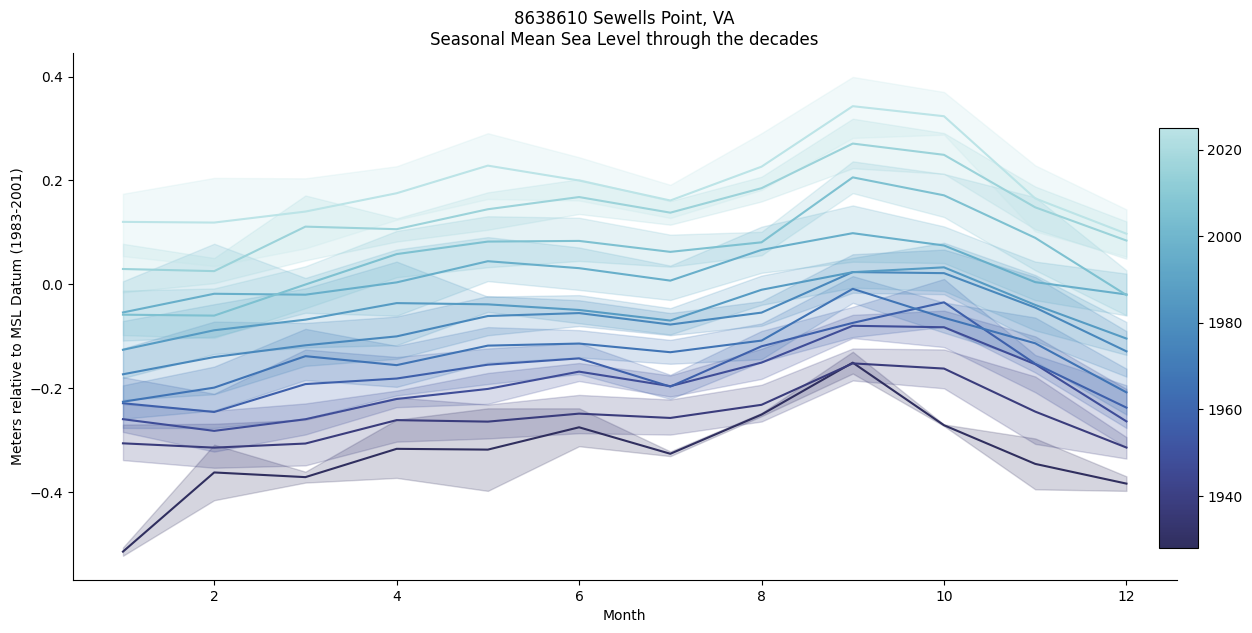

In [13]:
#@title Decadal Mean Sea Level

new_cmap = truncate_colormap(cmocean.cm.ice, 0.2, 0.9)
# Create the decadal mean sea level plot
s = sns.relplot(data=filtered_df, x='month', y='MSL', hue='decade', kind="line", palette=new_cmap, height=6, aspect=12/6)
norm = plt.Normalize(filtered_df['year'].min(), filtered_df['year'].max())
sm = plt.cm.ScalarMappable(cmap=new_cmap, norm=norm)
sm.set_array([])

# Remove the default legend from the plot
s._legend.remove()

# Add the colorbar manually
cbar_ax = s.fig.add_axes([0.91, 0.15, 0.03, 0.7])  # Adjust the position as needed
s.fig.colorbar(sm, cax=cbar_ax)

# Set plot labels and title based on units
if units == 'metric':
    s.set(xlabel='Month', ylabel='Meters relative to MSL Datum (' + epoch_info + ')',
          title=station_info + '\nSeasonal Mean Sea Level through the decades')
else:
    s.set(xlabel='Month', ylabel='Feet relative to MSL Datum (' + epoch_info + ')',
          title='Seasonal Mean Sea Level through the decades')


## **Step 7**

## **Calculating Trends in relative water levels**

## Statistical analysis and plotting of trends

#### Walking through the process of calculating the trends as seen in [CO-OPS Trends and Extremes Product](https://tidesandcurrents.noaa.gov/trends-and-extremes)

#### *** The trend calculations in this notebook may vary from the trend calculations on the website listed above.


*   The primary difference is that this notebook is in Python and the trends on the website are calculated using the R programming language. Python and R have different packages/libraries with different capabilities. It is expected to see some variations in using different languages/packages for running the Autoregressive Integrated Moving Average (ARIMA) model. The ARIMA model call and order in this notebook is the same as that run in R to produce the trends on the website, just with different packages/libraries.

This section walks through how the sea level (SL) trends are calculated using an Autoregressive Integrated Moving Average (ARIMA) model.

Because we are focused strictly on the autoregressive component of the data, we utilize the simplest form of this model: ARIMA (1,0,0).

For a comprehensive explanation of our statistical methodology—including why we rely solely on the autoregressive (AR) term and how we account for seasonality using exogenous variables—please refer to our official reports:

*   [NOAA technical service publication NOS CO-OPS 004: "NOAA's sea level trends"](https://repository.library.noaa.gov/view/noaa/74092)
*   [NOAA Technical Report NOS CO-OPS 53: "Sea Level Variations of the United States 1854-2006"](https://tidesandcurrents.noaa.gov/publications/Tech_rpt_53.pdf)
*   [NOAA Technical Report NOS CO-OPS 36: "Sea Level Variations of the United States 1854-1999"](https://tidesandcurrents.noaa.gov/publications/NOAA_Technical_Report_NOS_COOPS_036.pdf)



Click [here](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html#) for documentation on the ARIMA model in python.

In [14]:
# @title
trend_value = my_trend['seaLvlTrend.trend'].iloc[0]
if pd.isna(trend_value) or trend_value == 'None':
    print('This station does not meet the data requirements for the calculation of an NTDE trend.')
else:
  df_msl = df_msl.set_index(df_msl.month)

  #set index to date
  df_msl.set_index(df_msl.date,inplace=True)

  # We use a monthly frequency ('MS' for month-start).
  start_year = 1992
  end_date = df_msl.index.max()
  full_date_range = pd.date_range(start=f'{start_year}-01-01', end=end_date, freq='MS')

  # Reindex the MSL data to the full date range.
  # This creates a complete time series from 1992.
  # Any months without data in the original df_msl will have their 'MSL' value as NaN.
  msl_full_range = df_msl['MSL'].reindex(full_date_range)

  # Create a new DataFrame for the complete trend timeframe
  trend_timeframe = pd.DataFrame(msl_full_range)
  trend_timeframe.index.name = 'date'

  # Calculate the decimal date for the time variable in the model
  # (e.g., mid-February 2020 becomes 2020.125)
  trend_timeframe.index = pd.to_datetime({
          'year': trend_timeframe.index.year,
          'month': trend_timeframe.index.month,
          'day': 15
      })

  # The updated formula to account for the middle of the month
  trend_timeframe['decimal_date'] = trend_timeframe.index.year + (trend_timeframe.index.month - 1 + 0.5) / 12

  #create matrix for ARIMA model, this is the format that the MSL data is in prior to the ARIMA model
  matrix_data = pd.DataFrame()
  matrix_data['time1']=trend_timeframe['decimal_date']-2000
  matrix_data['month']=trend_timeframe.index.month
  matrix_data['msl']=trend_timeframe['MSL']
  matrix_data['mon1']=matrix_data['month'].apply(lambda x: 1 if x == 1 else 0)
  matrix_data['mon2']=matrix_data['month'].apply(lambda x: 1 if x == 2 else 0)
  matrix_data['mon3']=matrix_data['month'].apply(lambda x: 1 if x == 3 else 0)
  matrix_data['mon4']=matrix_data['month'].apply(lambda x: 1 if x == 4 else 0)
  matrix_data['mon5']=matrix_data['month'].apply(lambda x: 1 if x == 5 else 0)
  matrix_data['mon6']=matrix_data['month'].apply(lambda x: 1 if x == 6 else 0)
  matrix_data['mon7']=matrix_data['month'].apply(lambda x: 1 if x == 7 else 0)
  matrix_data['mon8']=matrix_data['month'].apply(lambda x: 1 if x == 8 else 0)
  matrix_data['mon9']=matrix_data['month'].apply(lambda x: 1 if x == 9 else 0)
  matrix_data['mon10']=matrix_data['month'].apply(lambda x: 1 if x == 10 else 0)
  matrix_data['mon11']=matrix_data['month'].apply(lambda x: 1 if x == 11 else 0)
  matrix_data['mon12']=matrix_data['month'].apply(lambda x: 1 if x == 12 else 0)

  matrix_data = matrix_data.drop('month',axis=1)

  msl = pd.DataFrame(matrix_data['msl'])

  matrix_data = matrix_data.drop('msl',axis=1)

  exog=matrix_data

  if units == 'metric':
      model=ARIMA(endog=msl*1000,exog=exog,order=(1,0,0),trend='n')
  else:
  #if english, we want in inches instead of ft
    model=ARIMA(endog=msl*12,exog=exog,order=(1,0,0), trend='n')
  model_fit = model.fit()

  print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    msl   No. Observations:                  408
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2292.617
Date:                Mon, 05 Oct 2026   AIC                           4615.234
Time:                        20:03:21   BIC                           4675.403
Sample:                             0   HQIC                          4639.043
                                - 408                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
time1          6.3245      0.525     12.047      0.000       5.296       7.353
mon1         -51.1935     12.312     -4.158      0.000     -75.325     -27.062
mon2         -40.8964     10.906     -3.750      0.0

### Curious about the model performance?

### Here we have the diagnostics of the ARIMA model where we can look for anything unusual in our model

*   The top left plot shows the residuals over time. We want it to appear to be white
noise and not display any seasonality.
*   The top right plot shows a histogram with a Kernel Density Estimate (KDE) and N(0,1) line. The N(0,1)  is the standard notation for a normal distribution with mean 0 and std of 1. If the KDE follows closely with the N(0,1), it is a good indication that the residuals are normally distributed.
*   The bottom left plot is a qq-plot that shows the ordered distribution of residuals (blue dots) and the linear trend of the samples (red line) taken from a standard normal distribution with N(0,1). If the blue dots follow the linear trend, it is a strong indication that the residuals are normally distributed.
*   The bottom right is a correlogram which shows if the time series residuals have high or low correlation with lagged versions of itself (autocorrelation).


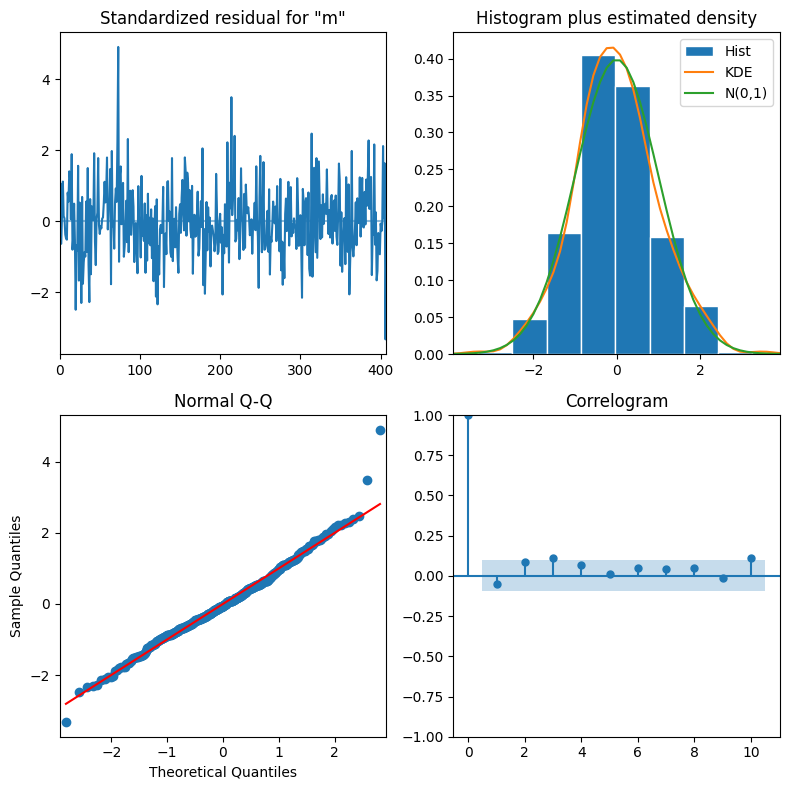

In [15]:
# @title
# KDE = kernel density estimate
# Q-Q plot = quantile/quantile
if pd.isna(trend_value) or trend_value == 'None':
    print('This station does not meet the data requirements for the calculation of an NTDE trend.')
else:
  fig = model_fit.plot_diagnostics(figsize=(8, 8))
  # The 'Standardized residuals' plot is the first one, at index 0.
  ax_residuals = fig.axes[0]

  # Use standard Matplotlib methods to remove the x-axis elements
  ax_residuals.set_xlabel("")         # Removes the "Date" label

  #Readjust the layout and display the modified plot
  plt.tight_layout()
  plt.show()

### Next, we can dive into the seasonal cycle.
#### The average seasonal cycle of mean sea level is caused by regular fluctuations in coastal temperatures, salinities, winds, atmospheric pressures and ocean currents over time.

In [16]:
 # @title
if pd.isna(trend_value) or trend_value == 'None':
  print('This station does not meet the data requirements for the calculation of an NTDE trend.')
else:
  seasonal_coefs = [model_fit.params[f'mon{i}'] for i in range(1, 13)]
  seasonal_avg = sum(seasonal_coefs) / 12
  months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

  if units == 'metric':
      # Convert from mm to meters
        zero_mean_seasonality = [round((coef - seasonal_avg) / 1000,3) for coef in seasonal_coefs]
        yaxis_title = 'Deviation from Seasonal Average (m)'
        yaxis_range = [-0.15, 0.15]
  else: # english
        # Convert from inches to feet
        zero_mean_seasonality = [round((coef - seasonal_avg) / 12,2) for coef in seasonal_coefs]
        yaxis_title = 'Deviation from Seasonal Average (ft)'
        yaxis_range = [-0.5, 0.5]

  fig_seasonal = go.Figure()
  fig_seasonal.add_trace(go.Bar(
            x=months,
            y=zero_mean_seasonality
        ))

  fig_seasonal.update_layout(
        title=dict(
            text="Average Seasonal Cycle",
            x=0.5,  # Center the title
            xanchor='center',
            font=dict(size=15)
        ),
            yaxis_title=yaxis_title,
            template='plotly_white',
            yaxis_range=yaxis_range,
            height=650,
            width=1250
        )
  fig_seasonal.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGray')

  fig_seasonal.show()


In [17]:
# @title Plotting the trend and 95% confidence intervals
if pd.isna(trend_value) or trend_value == 'None':
  print('This station does not meet the data requirements for the calculation of an NTDE trend.')
else:
  #get info from model
  coefs=model_fit.params
  se=model_fit.bse

  #extracting our trend information from model
  if units == 'metric':
    trend_text=str(np.round(coefs[0],2)) +' +/- '+str(np.round(se[0]*1.96,2))+' mm/yr'
    slope_m = coefs[0]/1000
    error_m = (se[0]*1.96)/1000
  else:
    trend_text = f"{np.round(coefs[0] * 10, 2)} +/- {np.round(se[0] * 1.96 * 10, 2)} in/decade"
    slope_m = (coefs[0] / 12)
    error_m = (se[0] * 1.96 / 12)

  print(trend_text)

6.32 +/- 1.03 mm/yr


In [18]:
# @title
if pd.isna(trend_value) or trend_value == 'None':
  print('This station does not meet the data requirements for the calculation of an NTDE trend.')
else:
  #function to find y-int
  def getYInt(x1, y1,slope):
        y_intercept = slope * (-x1)+y1
        return (y_intercept)

  msl_adjust = df_msl[df_msl['date']>='1992-01-01']
  msl_adjust['decimal_date'] = msl_adjust.index.year + (msl_adjust.index.month - 1 + 0.5) / 12
  msl_adjust.index = pd.to_datetime({
        'year': msl_adjust.index.year,
        'month': msl_adjust.index.month,
        'day': 15
    })

  # Create a mapping from month (1–12) to seasonal mean
  month_to_seasonal = dict(zip(range(1, 13), zero_mean_seasonality))

  # Create the adjusted MSL column by subtracting the monthly seasonal mean
  msl_adjust['msl_seasonal_adjust'] = msl_adjust['MSL'].subtract(
        msl_adjust.index.month.map(month_to_seasonal)
    )

  #grabbing the months result from arima model
  seasonal = coefs[2:14]
  if units == 'metric':
    #calculating the mean seasonal and adding it to the trend line
    seasonal = np.mean(seasonal)/1000
  else:
    seasonal = np.mean(seasonal) / 12
  lin_y_int = getYInt(2000,seasonal,slope_m)

  #calculating liner trend
  msl_adjust['linear_trend'] = slope_m*msl_adjust['decimal_date']+lin_y_int
  #manually calculate se of estimate
  msl_adjust['y_y2']=(msl_adjust['msl_seasonal_adjust']-msl_adjust['linear_trend'])**2
  y_y2_sum = msl_adjust['y_y2'].sum()
  msl_adjust['se_regression'] = np.sqrt(y_y2_sum / (len(msl_adjust) - 2))

  #calculate standard error of the regression line at each point
  one_over_n = 1/len(msl_adjust)
  msl_adjust['x_x2'] = (msl_adjust['decimal_date']-msl_adjust['decimal_date'].mean())**2
  msl_adjust['sum_x_x2'] = msl_adjust['x_x2'].sum()
  msl_adjust['sqrt'] = np.sqrt(one_over_n+(msl_adjust['x_x2']/msl_adjust['sum_x_x2']))
  msl_adjust['se_point'] = (msl_adjust['se_regression'])*msl_adjust['sqrt']

  # get variance inflation factor (VIF)
  p1 = coefs[-2]
  VIF = ((1 + p1) / (1 - p1)) ** 0.5
  # Calculate standard error of the regression line at each point
  msl_adjust['se_point_vif'] = msl_adjust['se_point'] * VIF

  #confidence bands
  msl_adjust['upr'] = msl_adjust['linear_trend']+1.96*msl_adjust['se_point_vif']
  msl_adjust['lwr'] = msl_adjust['linear_trend']-1.96*msl_adjust['se_point_vif']

## Now, we will plot our trend from the National Tidal Datum Epoch (NTDE) 1983-2001 to present. The rate of change was computed from the central midpoint of NTDE 1983-2001 (1992.5) to the end of the most recent year with data (2025).  

In [19]:
# @title
if pd.isna(trend_value) or trend_value == 'None':
  print('This station does not meet the data requirements for the calculation of an NTDE trend.')
else:
  # Create figure
  fig = go.Figure()

  # Add traces
  fig.add_trace(go.Scatter(x=msl_adjust.index, y=msl_adjust["msl_seasonal_adjust"],
                            mode='lines', name='Monthly mean sea level with the average seasonal cycle removed',
                            line=dict(color='cornflowerblue')))

  fig.add_trace(go.Scatter(x=msl_adjust.index, y=msl_adjust["linear_trend"],
                            mode='lines', name='Linear Relative Sea Level Trend',
                            line=dict(color='red')))

  fig.add_trace(go.Scatter(x=msl_adjust.index, y=msl_adjust["upr"],
                            mode='lines', name='Upper 95% Confidence Interval',
                            line=dict(color='black')))

  fig.add_trace(go.Scatter(x=msl_adjust.index, y=msl_adjust["lwr"],
                            mode='lines', name='Lower 95% Confidence Interval',
                            line=dict(color='black')))

  # Y-axis label and limits
  if units == 'metric':
        yaxis_title = "Meters"
        if station in ['8771450', '8761724']:
            y_range = [-0.75, 0.6]
        elif station == '9453220':
            y_range = [-0.45, 1.35]
        elif station == '9455090':
            y_range = [-1.35, 0.45]
        else:
            y_range = [-0.6, 0.6]
  else:
        yaxis_title = "Feet"
        y_range = [-2.5, 2] if station in ['8771450','8761724'] else [-2, 2]

  # Update layout with grid lines
  fig.update_layout(
        title=dict(
            text=f"Relative Sea Level Trend<br><br>{station_info} &nbsp;&nbsp;&nbsp;&nbsp; {trend_text}",
            x=0.5,  # Center the title
            xanchor='center',
            font=dict(size=15)
        ),
        xaxis_title="Year",
        yaxis_title=yaxis_title,
        xaxis=dict(showgrid=True),
        yaxis=dict(showgrid=True, range=y_range, zeroline=True, zerolinecolor='black'),
        template="simple_white",
        legend=dict(x=0.01, y=0.99),
        width=1250,
        height=650
    )

  # Show the figure
  fig.show()

## How has sea level changed over time?

Now we will plot the variation of 30-year trends.

*   30-year trends calculated in one year increments
*   Each trend point is plotted at the midpoint of the 30-year period



In [31]:
# @title

try:
    product = "observedSL"
    affil = "us"
    server = "https://api.tidesandcurrents.noaa.gov/dpapi/prod/webapi/product/"

    # Ensure station and units variables are defined in a previous cell
    myurl = (server + product + ".json?station=" + station + '&units=' + units + "&trendType=30YEAR")
    print(myurl)
    # Use requests to get the data
    urlResponse = requests.get(myurl)
    content = urlResponse.json()

    # Access the new primary key
    mydata = content['SeaLvlTrends']

    # Use json_normalize to unpack the 'trends' array into individual rows.
    # The 'meta' parameter keeps the higher-level station data attached to each row.
    my_trend = pd.json_normalize(
        mydata,
        record_path='trends',
        meta=['stationId', ['metadata', 'stationName']]
    )

    # Access the flattened column names.
    station_info = my_trend['stationId'].iloc[0] + ' ' + my_trend['metadata.stationName'].iloc[0]

    # Note: .iloc[0] gets the dates for the FIRST 30-year window in the list.
    # If you want the dates for the most recent window, you would use .iloc[-1]
    start_trend = pd.to_datetime(my_trend['startDate'].iloc[0])
    end_trend = pd.to_datetime(my_trend['endDate'].iloc[0])

    # Display the dataframe
    print(my_trend.head())
    variation_error = False
except Exception as e:
    variation_error = True
    print(f'No 30-year trends available for this station. Error details: {e}')

https://api.tidesandcurrents.noaa.gov/dpapi/prod/webapi/product/observedSL.json?station=8638610&units=metric&trendType=30YEAR
    startDate     endDate  trend  trendError  autoregressive  \
0  01/15/1928  12/15/1957   5.58        0.42            0.17   
1  01/15/1929  12/15/1958   5.41        0.41            0.16   
2  01/15/1930  12/15/1959   4.76        0.44            0.20   
3  01/15/1931  12/15/1960   4.55        0.44            0.21   
4  01/15/1932  12/15/1961   4.42        0.46            0.22   

   autoregressiveError stationId metadata.stationName  
0                 0.06   8638610        Sewells Point  
1                 0.05   8638610        Sewells Point  
2                 0.05   8638610        Sewells Point  
3                 0.05   8638610        Sewells Point  
4                 0.05   8638610        Sewells Point  


## Has our trend changed over time?

The plot below shows how 30-year trends vary over time. Each point represents the trend for a 30-year rolling window, plotted at the midpoint of that period. This visualization helps us see whether the trends are consistent (linear), accelerating, or decelerating.

In [21]:
# @title
if variation_error == True:
  print('This station does not meet the data requirements for the variaiton of 30 year trends.')
else:
  # Calculate mid_year by averaging the start and end years
  start_years = pd.to_datetime(my_trend['startDate']).dt.year
  end_years = pd.to_datetime(my_trend['endDate']).dt.year
  my_trend['mid_year'] = (start_years + end_years) / 2

  # Calculate the confidence intervals using the trendError
  my_trend['high_conf'] = my_trend['trend'] + my_trend['trendError']
  my_trend['low_conf'] = my_trend['trend'] - my_trend['trendError']

  # Extract station info dynamically for the title
  station = my_trend['stationId'].iloc[0]
  station_name = my_trend['metadata.stationName'].iloc[0]

  # configurations
  PLOT_WIDTH = 1250
  PLOT_HEIGHT = 650
  TITLE_FONT_SIZE = 34
  SUBTITLE_FONT_SIZE = 20
  AXIS_TITLE_FONT_SIZE = 26
  TICK_FONT_SIZE = 22
  LEGEND_FONT_SIZE = 18

  # Dynamic X-Axis Calculation
  # Find the first and last year in the dataset, then add the 15-year buffer
  min_year = my_trend['mid_year'].min()
  max_year = my_trend['mid_year'].max()

  x_start = min_year - 15
  x_end = max_year + 15

  # Build the Figure
  fig = go.Figure()

  # Upper Bound of Confidence Interval (Invisible line)
  fig.add_trace(go.Scatter(
      x=my_trend['mid_year'],
      y=my_trend['high_conf'],
      mode='lines',
      line=dict(width=0),
      showlegend=False,
      hoverinfo='skip'
  ))

  # Lower Bound of Confidence Interval (Fills to Upper Bound)
  fig.add_trace(go.Scatter(
      x=my_trend['mid_year'],
      y=my_trend['low_conf'],
      mode='lines',
      line=dict(width=0),
      fillcolor='rgba(208, 226, 236, 0.6)',
      fill='tonexty',
      name='90% Confidence Interval'
  ))

  # Main Trend Line
  fig.add_trace(go.Scatter(
      x=my_trend['mid_year'],
      y=my_trend['trend'],
      mode='lines',
      line=dict(color='#21497a', width=4),
      name='Trend Rate'
  ))

  # Update Layout and Styling
  fig.update_layout(
      title=dict(
          text=f"<b>Variation of 30-Year Relative Sea Level Trends</b><br><span style='font-size: {SUBTITLE_FONT_SIZE}px; color: #555;'>{station} {station_name}</span>",
          x=0.5,
          y=0.95,
          xanchor='center',
          font=dict(size=TITLE_FONT_SIZE, color='#333')
      ),
      xaxis=dict(
          title="<b>Mid Year</b>",
          titlefont=dict(size=AXIS_TITLE_FONT_SIZE),
          tickfont=dict(size=TICK_FONT_SIZE),
          range=[x_start, x_end],
          showgrid=True,
          gridcolor='lightgray',
          griddash='dash'
      ),
      yaxis=dict(
          title="<b>Trend Rate</b>",
          titlefont=dict(size=AXIS_TITLE_FONT_SIZE),
          tickfont=dict(size=TICK_FONT_SIZE),
          showgrid=True,
          gridcolor='lightgray',
          griddash='dash',
          zeroline=True,
          zerolinecolor='black',
          zerolinewidth=1.5
      ),
      template="simple_white",
      width=PLOT_WIDTH,
      height=PLOT_HEIGHT,
      margin=dict(t=120, b=100, l=120, r=50),
      legend=dict(
          font=dict(size=LEGEND_FONT_SIZE),
          x=0.01, y=0.98,
          bordercolor="black",
          borderwidth=1,
          bgcolor="rgba(255,255,255,0.9)"
      )
  )

  fig.show()

## **Step 8**

## How has the **amount** of sea level changed over time?

Next we will calculate the amount of change for the station's period of record (POR) as well as since the NTDE.

In [22]:
# @title Change over the POR

# configurations
UNIT = "m"
station_info = station + " " + station_name
LINE_WIDTH_MONTHLY = 1
MONTHLY_OPACITY = 0.32
LINE_WIDTH_ANNUAL = 2
ANNUAL_OPACITY = 1.0
LINE_WIDTH_MARKER = 6
FONT_SIZE_TITLE = 32
FONT_SIZE_AXIS_TITLE = 22
FONT_SIZE_TICKS = 18
FONT_SIZE_ANNOTATION = 16
FONT_SIZE_LEGEND = 18
PLOT_WIDTH = 1250
PLOT_HEIGHT = 650

# Data processing & QC
# Ensure index is datetime
df_msl.index = pd.to_datetime(df_msl['date'])

# SLIDING WINDOW: Find the first 5-year period with 70% data (42 months)
required_months = 42
valid_start_date = None
valid_end_date = None
first_5_data = None

# Create a list of dates that actually have 'MSL' data in them
dates_with_data = df_msl['MSL'].dropna().index.sort_values().unique()

# Loop chronologically only through dates that have data
for current_date in dates_with_data:
    # Define the 5-year window for the current date
    end_date = current_date + pd.DateOffset(years=5)

    # Slice the data for this window and drop missing values
    window_data = df_msl[(df_msl.index >= current_date) & (df_msl.index < end_date)]['MSL'].dropna()

    # Check if this window meets the 70% criteria
    if len(window_data) >= required_months:
        valid_start_date = current_date
        valid_end_date = end_date
        first_5_data = window_data
        break # Exit the loop immediately since we found our first valid window!

# Handle the case where NO 5-year window meets the criteria
if valid_start_date is None:
    print(f"Data Availability Error: Could not find any 5-year period with at least {required_months} valid months.")
else:
    # Calculate the midpoint of the valid first 5 years
    mid_start_date = valid_start_date + (valid_end_date - valid_start_date) / 2

    # Calculate the end dates and end midpoint early so we can check our rules
    annual_avg_series = df_msl['MSL'].resample('YE').mean().dropna()
    end_dates = [annual_avg_series.index[-5], annual_avg_series.index[-1]]
    mid_end_date = end_dates[0] + (end_dates[1] - end_dates[0]) / 2

    # Calculate time differences for our validation checks
    years_diff = round((mid_end_date - mid_start_date).days / 365.25)

    absolute_data_start = df_msl.index.min()
    years_past_start = (mid_start_date - absolute_data_start).days / 365.25

    # Data validation check
    is_data_valid = True # We assume the data is good until proven otherwise

    # Check: Is the timeframe between midpoints less than 25 years?
    if years_diff < 25:
        print(f"Data Validation Error: Station fails criteria. The period between midpoints is only {years_diff} years (minimum 25)")
        is_data_valid = False

    # Only proceed with printing success and plotting if the data passed the check
    if is_data_valid:
        # Snap the printed dates strictly to the 15th of their respective months
        display_start_date = valid_start_date.replace(day=15)
        display_mid_date = mid_start_date.replace(day=15)

        print(f"The first valid 5-year period starts on {display_start_date.strftime('%Y-%m-%d')}.")
        print(f"--> The midpoint of this 5-year period is: {display_mid_date.strftime('%Y-%m-%d')}")

        # Calculate the two baseline averages for the plot
        avg_first_5 = first_5_data.mean()
        avg_last_5 = annual_avg_series.tail(5).mean()
        delta_por = avg_last_5 - avg_first_5

        start_dates = [valid_start_date, valid_end_date]

        # Build the Plotly Figure
        fig = go.Figure()

        # Monthly Data
        fig.add_trace(go.Scatter(
            x=df_msl.index, y=df_msl['MSL'],
            mode='lines', name='Monthly Average',
            line=dict(color='royalblue', width=LINE_WIDTH_MONTHLY),
            opacity=MONTHLY_OPACITY
        ))

        # Horizontal Baseline (Connects start to the modern vertical)
        fig.add_trace(go.Scatter(
            x=[start_dates[0], mid_end_date],
            y=[avg_first_5, avg_first_5],
            mode='lines',
            name='Historical Baseline Level',
            line=dict(color='black', width=2, dash='dash'),
            showlegend=False, hoverinfo='skip'
        ))

        # The Vertical Line (The Red Measurement Line)
        fig.add_trace(go.Scatter(
            x=[mid_end_date, mid_end_date],
            y=[avg_first_5, avg_last_5],
            mode='lines',
            name='Amount of Change',
            line=dict(color='red', width=4),
            hoverinfo='skip'
        ))

        # Annual Trend
        fig.add_trace(go.Scatter(
            x=annual_avg_series.index, y=annual_avg_series,
            mode='lines', name='Annual Average',
            opacity=ANNUAL_OPACITY,
            line=dict(color='royalblue', width=LINE_WIDTH_ANNUAL)
        ))

        # 5-year Period Markers (The "Goalposts")
        fig.add_trace(go.Scatter(
            x=start_dates, y=[avg_first_5, avg_first_5],
            mode='lines', name='5-yr Average',
            line=dict(color='black', width=LINE_WIDTH_MARKER)
        ))

        fig.add_trace(go.Scatter(
            x=end_dates, y=[avg_last_5, avg_last_5],
            mode='lines', showlegend=False, name='5-yr Average',
            line=dict(color='black', width=LINE_WIDTH_MARKER)
        ))

        # Floating annotation
        fig.add_annotation(
            x=mid_end_date,
            y=(avg_first_5 + avg_last_5) / 2,
            text=f"<b>{delta_por:.2f}{UNIT} change over {years_diff} years</b><br><span style='font-size:12px'></span>",
            font=dict(size=FONT_SIZE_ANNOTATION, color="red"),
            showarrow=True,
            arrowhead=2,
            arrowcolor="red",
            ax=80,
            ay=0,
            xanchor="left",
            bgcolor="white",
            bordercolor="red",
            borderwidth=2,
            borderpad=10
        )

        fig.update_layout(
            title=dict(text=f"<b>Sea Level Change: {station_info}</b>", font=dict(size=FONT_SIZE_TITLE), x=0.5, y=0.95),
            xaxis=dict(
                title="<b>Year</b>",
                titlefont=dict(size=FONT_SIZE_AXIS_TITLE),
                tickfont=dict(size=FONT_SIZE_TICKS),
                showgrid=True,
                gridcolor='lightgray',
                range=[df_msl.index.min(), df_msl.index.max() + pd.Timedelta(days=365*8)]
            ),
            yaxis=dict(
                title=f"<b>Mean Sea Level ({UNIT})</b>",
                titlefont=dict(size=FONT_SIZE_AXIS_TITLE),
                tickfont=dict(size=FONT_SIZE_TICKS),
                showgrid=True,
                gridcolor='lightgray',
                range=[-0.6, 0.6]
            ),
            template="simple_white",
            width=PLOT_WIDTH,
            height=PLOT_HEIGHT,
            margin=dict(t=120, b=100, l=120, r=250),
            legend=dict(font=dict(size=FONT_SIZE_LEGEND), x=0.01, y=0.98, bordercolor="black", borderwidth=1, bgcolor="rgba(255,255,255,0.9)")
        )

        fig.show()

The first valid 5-year period starts on 1927-08-15.
--> The midpoint of this 5-year period is: 1930-01-15


For the change since NTDE calculation, we must first check if the station is on the current NTDE datum. For stations not on the NTDE, we must calculate an offset to bring the data relative to the NTDE.

In [23]:
# @title Change since NTDE
# Control vs. Subordinate Station
ctrl_station = datums_meta.get('ctrlStation', '').strip()
if not ctrl_station:
    print(f"Hierarchy: Station {station} is a Control Station.\n")
else:
    print(f"Hierarchy: Station {station} is a Subordinate Station.")
    print(f"Control Station ID: {ctrl_station}")
    analysis_period_list = datums_meta.get('DatumAnalysisPeriod', ['Dates not available'])
    if analysis_period_list:
        print(f"Dates of Comparison: {analysis_period_list[0]}\n")
#first we need to check if our station requires an offset
if station in ['8770613','8771013','9455760']:
  print('This station is a subordinate station on a MTDE datum. We cannot accurately adjust the data to the NTDE.')
elif epic_mid != 1992 or station in ['8771450','8771510','8770570','8771341','8770822','8772471','9455920','9462620']:
  print('Station is not on the NTDE. Computing an offset based on the monthly means frim 1983-2001 to put station relative to the NTDE.')
  # Baseline calculation (1983-2001)
  epoch_data = df_msl.loc['1983-01-01':'2001-12-31']
  avg_msl_83_01 = epoch_data['MSL'].mean()

  # Apply Offset
  df_msl['MSL_Offset'] = df_msl['MSL'] - avg_msl_83_01

  msl_complete = df_msl

  # Annual Average Series
  annual_avg_series = msl_complete['MSL_Offset'].resample('YE').mean().dropna()

  # Calculate the two baseline averages
  avg_first_5 = first_5_data.mean()
  avg_last_5 = annual_avg_series.tail(5).mean()
  delta_por = avg_last_5 - avg_first_5

  # Define date ranges for the black markers
  start_dates = [first_date, end_first_5_date]
  end_dates = [annual_avg_series.index[-5], annual_avg_series.index[-1]]

  # Calculate the midpoint of the final 5 years to drop the vertical crosshair line
  mid_end_date = end_dates[0] + (end_dates[1] - end_dates[0]) / 2

  # Define our dates for the baseline and the total change measurement
  epoch_start = "1983-01-01"
  epoch_end = "2001-12-31"
  plot_end_date = "2031-01-01"
  midpoint_23 = pd.Timestamp("2023-07-02")
  baseline_epoch = 0

  fig = go.Figure()

  # Monthly Data
  fig.add_trace(go.Scatter(
      x=msl_complete['1982':].index,
      y=msl_complete['1982':]['MSL_Offset'],
      mode='lines', name='Monthly Average',
      line=dict(color='royalblue', width=LINE_WIDTH_MONTHLY),
      opacity=MONTHLY_OPACITY
  ))

  # Annual Trend
  fig.add_trace(go.Scatter(
      x=annual_avg_series.index, y=annual_avg_series,
      mode='lines', name='Annual Average',
      opacity=ANNUAL_OPACITY,
      line=dict(color='royalblue', width=LINE_WIDTH_ANNUAL)
  ))

  # Highlight the 1983-2001 epoch (Solid Black Line)
  fig.add_trace(go.Scatter(
      x=[epoch_start, epoch_end],
      y=[baseline_epoch, baseline_epoch],
      mode='lines',
      name='1983-2001 Epoch',
      line=dict(color='black', width=LINE_WIDTH_MARKER),
      hoverinfo='skip'
  ))

  # Post-epoch baseline (Dashed Black Line)
  fig.add_trace(go.Scatter(
      x=[epoch_end, 2024],
      y=[baseline_epoch, baseline_epoch],
      mode='lines',
      name='Baseline Continuation',
      line=dict(color='black', width=3, dash='dash'),
      showlegend=False,
      hoverinfo='skip'
  ))

  # The vertical rise (Solid Red Measurement Line)
  fig.add_trace(go.Scatter(
      x=[midpoint_23, midpoint_23],
      y=[baseline_epoch, avg_last_5],
      mode='lines',
      name='Total Change',
      line=dict(color='red', width=4),
      hoverinfo='skip'
  ))

  # Modern Average Line (The heavy black bar)
  fig.add_trace(go.Scatter(
      x=[pd.Timestamp("2021-01-01"), pd.Timestamp("2025-12-31")],
      y=[avg_last_5, avg_last_5],
      mode='lines', name='Current 5yr Avg',
      line=dict(color='black', width=LINE_WIDTH_MARKER)
  ))

  # red annotation box
  fig.add_annotation(
      x=midpoint_23,
      y=(baseline_epoch + avg_last_5) / 2,
      text=f"<b>TOTAL CHANGE</b><br>{avg_last_5:.2f}m",
      font=dict(size=FONT_SIZE_ANNOTATION, color="red"),
      showarrow=True,
      arrowhead=2,
      arrowcolor="red",
      ax=120,
      ay=0,
      bgcolor="white",
      bordercolor="red",
      borderwidth=2,
      borderpad=10
  )

  # Layout
  fig.update_layout(
      title=dict(text=f"<b>Sea Level Change: {station_info}</b>", font=dict(size=FONT_SIZE_TITLE), x=0.5, y=0.95),
      xaxis=dict(
          title="<b>Year</b>",
          titlefont=dict(size=FONT_SIZE_AXIS_TITLE),
          tickfont=dict(size=FONT_SIZE_TICKS),
          range=["1982-01-01", plot_end_date],
          showgrid=True,
          gridcolor='lightgray'
      ),
      yaxis=dict(
          title="<b>Mean Sea Level (m)</b>",
          titlefont=dict(size=FONT_SIZE_AXIS_TITLE),
          tickfont=dict(size=FONT_SIZE_TICKS),
          showgrid=True,
          gridcolor='lightgray',
          zeroline=False
      ),
      template="simple_white",
      width=PLOT_WIDTH,
      height=PLOT_HEIGHT,
      margin=dict(t=120, b=100, l=120, r=250),
      legend=dict(
          font=dict(size=FONT_SIZE_LEGEND),
          x=0.01, y=0.98,
          bordercolor="black",
          borderwidth=1,
          bgcolor="rgba(255,255,255,0.9)"
      )
  )
  fig.show()
else:
  print('Station is on the NTDE')
  msl_complete = df_msl

  # Annual Average Series
  annual_avg_series = msl_complete['MSL'].resample('YE').mean().dropna()

  # Define our dates for the baseline and the total change measurement
  epoch_start = "1983-01-01"
  epoch_end = "2001-12-31"
  plot_end_date = "2031-01-01"
  midpoint_23 = pd.Timestamp("2023-07-02")
  baseline_epoch = 0

  fig = go.Figure()

  # Monthly Data
  fig.add_trace(go.Scatter(
      x=df_msl['1982':].index,
      y=df_msl['1982':]['MSL'],
      mode='lines', name='Monthly Average',
      line=dict(color='royalblue', width=LINE_WIDTH_MONTHLY),
      opacity=MONTHLY_OPACITY
  ))

  # Annual Trend
  fig.add_trace(go.Scatter(
      x=annual_avg_series.index, y=annual_avg_series,
      mode='lines', name='Annual Average',
      opacity=ANNUAL_OPACITY,
      line=dict(color='royalblue', width=LINE_WIDTH_ANNUAL)
  ))

  # Highlight the 1983-2001 epoch (Solid Black Line)
  fig.add_trace(go.Scatter(
      x=[epoch_start, epoch_end],
      y=[baseline_epoch, baseline_epoch],
      mode='lines',
      name='1983-2001 Epoch',
      line=dict(color='black', width=LINE_WIDTH_MARKER),
      hoverinfo='skip'
  ))

  # Post-epoch baseline (Dashed Black Line)
  fig.add_trace(go.Scatter(
      x=[epoch_end, 2024],
      y=[baseline_epoch, baseline_epoch],
      mode='lines',
      name='Baseline Continuation',
      line=dict(color='black', width=3, dash='dash'),
      showlegend=False,
      hoverinfo='skip'
  ))

  # The vertical rise (Solid Red Measurement Line)
  fig.add_trace(go.Scatter(
      x=[midpoint_23, midpoint_23],
      y=[baseline_epoch, avg_last_5],
      mode='lines',
      name='Total Change',
      line=dict(color='red', width=4),
      hoverinfo='skip'
  ))

  # Modern Average Line (The heavy black bar)
  fig.add_trace(go.Scatter(
      x=[pd.Timestamp("2021-01-01"), pd.Timestamp("2025-12-31")],
      y=[avg_last_5, avg_last_5],
      mode='lines', name='Current 5yr Avg',
      line=dict(color='black', width=LINE_WIDTH_MARKER)
  ))

  # annotation box
  fig.add_annotation(
      x=midpoint_23,
      y=(baseline_epoch + avg_last_5) / 2,
      text=f"<b>TOTAL CHANGE</b><br>{avg_last_5:.2f}m",
      font=dict(size=FONT_SIZE_ANNOTATION, color="red"),
      showarrow=True,
      arrowhead=2,
      arrowcolor="red",
      ax=120,
      ay=0,
      bgcolor="white",
      bordercolor="red",
      borderwidth=2,
      borderpad=10
  )

  # layout
  fig.update_layout(
      title=dict(text=f"<b>Sea Level Change since NTDE: {station_info}</b>", font=dict(size=FONT_SIZE_TITLE), x=0.5, y=0.95),
      xaxis=dict(
          title="<b>Year</b>",
          titlefont=dict(size=FONT_SIZE_AXIS_TITLE),
          tickfont=dict(size=FONT_SIZE_TICKS),
          range=["1982-01-01", plot_end_date],
          showgrid=True,
          gridcolor='lightgray'
      ),
      yaxis=dict(
          title="<b>Mean Sea Level (m)</b>",
          titlefont=dict(size=FONT_SIZE_AXIS_TITLE),
          tickfont=dict(size=FONT_SIZE_TICKS),
          showgrid=True,
          gridcolor='lightgray',
          zeroline=False
      ),
      template="simple_white",
      width=PLOT_WIDTH,
      height=PLOT_HEIGHT,
      margin=dict(t=120, b=100, l=120, r=250),
      legend=dict(
          font=dict(size=FONT_SIZE_LEGEND),
          x=0.01, y=0.98,
          bordercolor="black",
          borderwidth=1,
          bgcolor="rgba(255,255,255,0.9)"
      )
  )
  fig.show()

Hierarchy: Station 8638610 is a Control Station.

Station is on the NTDE


## **Step 10**
## Incorporating future SL observation-based trajectories and scenario-based projections.

### First, we will add in the [2022 Sea Level Rise Technical Report](https://oceanservice.noaa.gov/hazards/sealevelrise/sealevelrise-tech-report-sections.html) SL observation-based trajectories from data fit over 1970-2020 and extrapolated to 2050.

#### As stated earlier, these trajectories are from the csv file with data extracted from the 2022 report (it is not available via API) that we uploaded in the beginning of the notebook.

In [24]:
# @title
trajectories = pd.read_csv('TR_local_projections.csv')
lookup = pd.read_csv('Station_ID_lookup.csv')

if station in ['9414523','9418767','8726384','8761927','8771510','8772447','8778490','8779748','8570283','8573927','8635027',
                '8411250','8419870','2695540','9455090','8737048','8637689','8722670','8770822','8771341','8772471']:
    print('No trajectories for this station')
elif pd.isna(trend_value) or trend_value == 'None':
  print('This station does not meet the data requirements for the calculation of an NTDE trend. Please choose another station to proceed through the rest of the notebook.')
else:
  station_lookup = lookup.loc[lookup['STATION_ID']==int(station)]
  psmsl_id = station_lookup['PSMSL_id'].values[0]
  if psmsl_id == -1:
    station_tg = station_lookup['Station_NAME_tg'].values[0]
    station_df = trajectories.loc[trajectories['tg']==station_tg]
  else:
    station_df = trajectories.loc[trajectories['PSMSL_id']==psmsl_id]
  station_df['day'] = '01'
  station_df['month'] = '01'

  pd.options.mode.chained_assignment = None
  station_df['date'] = pd.to_datetime(dict(year=station_df.years,month=station_df.month,day=station_df.day))
  station_df = station_df.set_index('date')

  if units == 'metric':
    #convert mm to m
    station_df['rsl_trajectory_m'] = station_df['rsl_trajectory']*0.001
    station_df['rsl_obs_m'] = station_df['rsl_obs']*0.001
  else:
    #convert mm to ft
    station_df['rsl_trajectory_m'] = station_df['rsl_trajectory']*0.00328084
    station_df['rsl_obs_m'] = station_df['rsl_obs']*0.00328084
  #for plotting with future scenarios, all data will need to be offset to center around 2005

  epoch_96_14=station_df['1996':'2014']
  epoch_offset=np.nanmean(epoch_96_14['rsl_obs_m'])

  station_df['rsl_trajectory_offset'] = station_df['rsl_trajectory_m'] - epoch_offset

  median_df = station_df[station_df['percentiles']== 50]
  high_df = station_df[station_df['percentiles']== 83]
  low_df = station_df[station_df['percentiles']== 17]

  epoch_96_14=msl_adjust['1996':'2014']
  epoch_offset_msl=np.nanmean(epoch_96_14['msl_seasonal_adjust'])

  #offseting msl data to center at 2005
  msl_adjust['msl_offset']=msl_adjust.msl_seasonal_adjust-epoch_offset_msl
  msl_adjust['trend_offset']=msl_adjust.linear_trend-epoch_offset_msl
  msl_adjust['upr_offset']=msl_adjust.upr-epoch_offset_msl
  msl_adjust['lwr_offset']=msl_adjust.lwr-epoch_offset_msl

  msl_adjust=msl_adjust.dropna(subset=['msl_offset'])
  msl_adjust['annual_msl']=msl_adjust.groupby(by=msl_adjust.index.year)['msl_offset'].transform('mean')
  msl_adjust['day'] = '01'
  msl_adjust['month'] = '01'
  msl_adjust['year_date'] = pd.to_datetime(dict(year=msl_adjust.index.year,month=msl_adjust.month,day=msl_adjust.day))

  #offseting msl data to center at 2005 for long term series
  # Create the adjusted MSL column by subtracting the monthly seasonal mean
  df_msl['msl_seasonal_adjust'] = df_msl['MSL'].subtract(
        df_msl.index.month.map(month_to_seasonal)
    )
  df_msl['msl_offset']=df_msl.msl_seasonal_adjust-epoch_offset_msl

  df_msl=df_msl.dropna(subset=['msl_offset'])
  df_msl['annual_msl']=df_msl.groupby(by=df_msl.index.year)['msl_offset'].transform('mean')
  df_msl['day'] = '01'
  df_msl['month'] = '01'
  df_msl['year_date'] = pd.to_datetime(dict(year=df_msl.index.year,month=df_msl.month,day=df_msl.day))

  #for trajectories
  msl_adjust_recent = df_msl[df_msl.index>'1969-12-31']

In [25]:
# @title

# List of stations without trajectories
excluded_stations = ['9414523','9418767','8726384','8761927','8771510','8772447','8778490','8779748','8570283','8573927','8635027',
                '8411250','8419870','2695540','9455090','8737048','8637689','8722670','8770822','8771341','8772471']

if station in excluded_stations:
    print('No trajectories for this station')
elif pd.isna(trend_value) or trend_value == 'None':
    print('This station does not meet the data requirements for the calculation of an NTDE trend. Please choose another station to proceed through the rest of the notebook.')
else:
    fig = go.Figure()

    # Add MSL offset (monthly mean sea level)
    fig.add_trace(go.Scatter(
        x=msl_adjust_recent.index,
        y=msl_adjust_recent["msl_offset"],
        mode='lines',
        name='Monthly mean sea level with the average seasonal cycle removed',
        line=dict(color='cornflowerblue')
    ))

    # Add annual MSL (scatter line)
    fig.add_trace(go.Scatter(
        x=msl_adjust_recent.year_date,
        y=msl_adjust_recent['annual_msl'],
        mode='lines',
        name='Annual MSL',
        line=dict(color='darkblue')
    ))

    # Add median trajectory
    fig.add_trace(go.Scatter(
        x=median_df.index,
        y=median_df['rsl_trajectory_offset'],
        mode='lines',
        name='Median Observation-based Trajectory',
        line=dict(color='green')
    ))

    # Add high percentile trajectory
    fig.add_trace(go.Scatter(
        x=high_df.index,
        y=high_df['rsl_trajectory_offset'],
        mode='lines',
        name='83rd percentile Trajectory',
        line=dict(color='green', dash='dash')
    ))

    # Add low percentile trajectory
    fig.add_trace(go.Scatter(
        x=low_df.index,
        y=low_df['rsl_trajectory_offset'],
        mode='lines',
        name='17th percentile Trajectory',
        line=dict(color='green', dash='dash')
    ))

    # Set y-axis limits and label based on units
    if units == 'metric':
        yaxis_title = "Meters relative to 2005"
        y_range = [-0.5, 0.7] if station in ['8594900','8727520','8729840','8771450'] else [-0.6, 0.6]
    else:
        yaxis_title = "Feet relative to 2005"
        y_range = [-1.7, 2.3] if station in ['8594900','8727520','8729840','8771450'] else [-2, 2]

    fig.update_layout(
        title=dict(
            text=f"{station_info}<br>MSL over time compared to trajectory since 1970",
            x=0.5,
            xanchor='center',
            font=dict(size=15)
        ),
        xaxis=dict(
            title="Year",
            showgrid=True,            # Enable x-axis grid lines
            gridcolor='lightgray'
        ),
        yaxis=dict(
            title=yaxis_title,
            range=y_range,
            zeroline=True,
            zerolinecolor='black',
            showgrid=True,            # Enable y-axis grid lines
            gridcolor='lightgray'
        ),
        template="simple_white",
        legend=dict(x=0.01, y=0.99),
        width=1250,
        height=750
    )

    fig.show()


## Now, we will plot the 2022 SLR report SLR projections for each 5 scenarios

In [26]:
# @title
if station in ['9463502','9437540','8737048','8726384','8726674','8729210','8761927','8772447','8778490','8779748','8570283',
               '8573927','8631044','8635027','8637689','8419870','8423898','2695540','8771341']:
    print('This station does not have regional scenarios. Please choose another station to proceed through the notebook.')

else:
# Get SLR Projections from 2022 Tech Report
    product = "slr_projections"

    server = "https://api.tidesandcurrents.noaa.gov/dpapi/prod/webapi/product/"

    affil = "US"

    report_year='2022'

    myurl=(server+ product  + ".json?"+"units="+units+"&station=" + station + "&report_year=" + report_year+"&affil=" + affil)
    #print(myurl)
    # Use requests to get the data
    urlResponse = requests.get(myurl)
    content=urlResponse.json()

    # Assign data to variables
    mydata = content['SlrProjections']

    # Make it a Dataframe
    mydf_slr_projection = pd.DataFrame(mydata)
    mydf_slr_projection['day'] = '01'
    mydf_slr_projection['month'] = '01'
    mydf_slr_projection['year_date'] = pd.to_datetime(dict(year=mydf_slr_projection.projectionYear,
                                                           month=mydf_slr_projection.month,day=mydf_slr_projection.day))
    mydf_slr_projection=mydf_slr_projection[mydf_slr_projection['year_date']<'2101-01-01']

    # Break down SLR Projections by Scenario
    scenario_low=mydf_slr_projection[mydf_slr_projection['scenario']=='Low']
    scenario_low.reset_index(inplace=True,drop=True)
    scenario_intlow=mydf_slr_projection[mydf_slr_projection['scenario']=='Intermediate-Low']
    scenario_intlow.reset_index(inplace=True,drop=True)
    scenario_int=mydf_slr_projection[mydf_slr_projection['scenario']=='Intermediate']
    scenario_int.reset_index(inplace=True,drop=True)
    scenario_inthigh=mydf_slr_projection[mydf_slr_projection['scenario']=='Intermediate-High']
    scenario_inthigh.reset_index(inplace=True,drop=True)
    scenario_high=mydf_slr_projection[mydf_slr_projection['scenario']=='High']
    scenario_high.reset_index(inplace=True,drop=True)

    if units == 'metric':
      #converting from cm to m
      scenario_low_rslproj=scenario_low['projectionRsl']*0.01
      scenario_intlow_rslproj=scenario_intlow['projectionRsl']*0.01
      scenario_int_rslproj=scenario_int['projectionRsl']*0.01
      scenario_inthigh_rslproj=scenario_inthigh['projectionRsl']*0.01
      scenario_high_rslproj=scenario_high['projectionRsl']*0.01
    else:
      #converting from in to ft
      scenario_low_rslproj=scenario_low['projectionRsl']*0.0833333
      scenario_intlow_rslproj=scenario_intlow['projectionRsl']*0.0833333
      scenario_int_rslproj=scenario_int['projectionRsl']*0.0833333
      scenario_inthigh_rslproj=scenario_inthigh['projectionRsl']*0.0833333
      scenario_high_rslproj=scenario_high['projectionRsl']*0.0833333

In [27]:
# @title
# Skip stations without projections
excluded_stations = [
    '9463502','9437540','8737048','8726384','8726674','8729210','8761927',
    '8772447','8778490','8779748','8570283','8573927','8631044','8635027',
    '8637689','8419870','8423898','2695540','8771341'
]

if station in excluded_stations:
    print('This station does not have regional scenarios. Please choose another station to proceed through the notebook. Please choose another station to proceed through the rest of the notebook.')
elif pd.isna(trend_value) or trend_value == 'None':
  print('This station does not meet the data requirements for the calculation of an NTDE trend.')
else:
    fig = go.Figure()

    # Add annual MSL
    fig.add_trace(go.Scatter(
        x=msl_adjust_recent.year_date,
        y=msl_adjust_recent['annual_msl'],
        mode='lines',
        name='Annual MSL',
        line=dict(color='blue')
    ))

    # Add projection scenarios
    fig.add_trace(go.Scatter(
        x=scenario_low.year_date, y=scenario_low_rslproj,
        mode='lines', name='Low', line=dict(color='black')
    ))
    fig.add_trace(go.Scatter(
        x=scenario_intlow.year_date, y=scenario_intlow_rslproj,
        mode='lines', name='Intermediate Low', line=dict(color='purple')
    ))
    fig.add_trace(go.Scatter(
        x=scenario_int.year_date, y=scenario_int_rslproj,
        mode='lines', name='Intermediate', line=dict(color='pink')
    ))
    fig.add_trace(go.Scatter(
        x=scenario_inthigh.year_date, y=scenario_inthigh_rslproj,
        mode='lines', name='Intermediate High', line=dict(color='orange')
    ))
    fig.add_trace(go.Scatter(
        x=scenario_high.year_date, y=scenario_high_rslproj,
        mode='lines', name='High', line=dict(color='yellow')
    ))

    # Y-axis label
    yaxis_title = "Meters relative to 2005" if units == 'metric' else "Feet relative to 2005"

    # Layout with grid lines and centered title
    fig.update_layout(
        title=dict(
            text=f"{station_info}<br>Annual Relative Sea Level Since 1960 and Projections to 2100",
            x=0.5,
            xanchor='center',
            font=dict(size=15)
        ),
        xaxis=dict(
            title="Year",
            showgrid=True,
            gridcolor='lightgray'
        ),
        yaxis=dict(
            title=yaxis_title,
            showgrid=True,
            gridcolor='lightgray',
            zeroline=True,
            zerolinecolor='black'
        ),
        template="simple_white",
        legend=dict(x=0.01, y=0.99),
        width=1250,
        height=750
    )

    fig.show()

## Let's incorporate the background relative sea level from the 2022 SLR report
### We can use the background relative sea level (RSL) to examine the contribution of Vertical Land Motion to sea level.

### Tide gauge trends are relative to a fixed point on land and reflect both the changes in water level and local VLM. VLM can vary due to different factors such as glacial rebound, earthquakes, and ground-water withdrawal. A positive background sea level trend indicates that the land is sinking, thus contributing positively to sea level rise. A negative background sea level trend means the land is rising, thus contributing negatively to sea level rise.

In [28]:
# @title

if station in ['9463502','9437540','8737048','8726384','8726674','8729210','8761927','8772447','8778490','8779748','8570283',
               '8573927','8631044','8635027','8637689','8419870','8423898','2695540','8771341']:
  print('This station does not have background SL data. Please choose another station to proceed through the notebook. Please choose another station to proceed through the rest of the notebook.')
else:
  if units == 'metric':
    #all we have is the trend slope in cm/year
    rsl = mydf_slr_projection['backgroundRslPerYear'][0] * 0.01
    rsl_mm = mydf_slr_projection['backgroundRslPerYear'][0] * 10
    rsl_text=str(np.round(rsl_mm,2))+' mm/yr'
  else:
    rsl = mydf_slr_projection['backgroundRslPerYear'][0] * 0.0833333
    rsl_mm = mydf_slr_projection['backgroundRslPerYear'][0]
    rsl_text=str(np.round(rsl_mm,2))+' inches/yr'

  lin_trend = msl_adjust['trend_offset'].iloc[0]
  year_start = msl_adjust['decimal_date'].iloc[0]

  y_int = getYInt(year_start,lin_trend,rsl)
  msl_adjust['backgroundRsl']= rsl*msl_adjust['decimal_date']+y_int





In [29]:
# @title

excluded_stations = [
    '9463502','9437540','8737048','8726384','8726674','8729210','8761927',
    '8772447','8778490','8779748','8570283','8573927','8631044','8635027',
    '8637689','8419870','8423898','2695540','8771341'
]

if station in excluded_stations:
    print('This station does not have background SL data. Please choose another station to proceed through the notebook.')
elif pd.isna(trend_value) or trend_value == 'None':
    print('This station does not meet the data requirements for the calculation of an NTDE trend. Please choose another station to proceed through the rest of the notebook.')
else:
    fig = go.Figure()

    # Add traces
    fig.add_trace(go.Scatter(
        x=msl_adjust.index, y=msl_adjust["msl_offset"],
        mode='lines', name='Monthly MSL (seasonal cycle removed)',
        line=dict(color='cornflowerblue')
    ))

    fig.add_trace(go.Scatter(
        x=msl_adjust.index, y=msl_adjust['trend_offset'],
        mode='lines', name='Linear RSL Trend',
        line=dict(color='red')
    ))

    fig.add_trace(go.Scatter(
        x=msl_adjust.index, y=msl_adjust['upr_offset'],
        mode='lines', name='Upper 95% CI',
        line=dict(color='black', width=1)
    ))

    fig.add_trace(go.Scatter(
        x=msl_adjust.index, y=msl_adjust['lwr_offset'],
        mode='lines', name='Lower 95% CI',
        line=dict(color='black', width=1)
    ))

    fig.add_trace(go.Scatter(
        x=msl_adjust.index, y=msl_adjust['backgroundRsl'],
        mode='lines', name='Background RSL (VLM)',
        line=dict(color='brown', dash='dot', width=3)
    ))

    # Y-axis label and limits
    if units == 'metric':
        yaxis_title = "Meters relative to 2005"
        yaxis_range = [-0.75, 0.6] if station == '8771450' else [-0.6, 0.6]
    else:
        yaxis_title = "Feet relative to 2005"
        yaxis_range = [-2.5, 2] if station == '8771450' else [-2, 2]

    # Layout
    fig.update_layout(
        title=dict(
            text=f"Relative Sea Level Trend<br>{station_info}<br><br>NTDE SL Trend: {trend_text}<br>Background SL (VLM contribution): {rsl_text}",
            x=0.5,
            xanchor='center',
            font=dict(size=15)
        ),
        xaxis=dict(
            title="Year",
            showgrid=True,
            gridcolor='lightgray'
        ),
        yaxis=dict(
            title=yaxis_title,
            range=yaxis_range,
            showgrid=True,
            gridcolor='lightgray',
            zeroline=True,
            zerolinecolor='black'
        ),
        template="simple_white",
        legend=dict(x=0.01, y=0.99),
        width=1250,
        height=650
    )

    fig.show()

## Now, we can plot everything together!

In [30]:
# @title

excluded_stations = [
    '9463502','9437540','8737048','8726384','8729210','8761927','8772447',
    '8778490','8779748','8570283','8573927','8631044','8635027','8637689',
    '8419870','8423898','2695540','9414523','9418767','9455090','8411250','8771341'
]

if station in excluded_stations:
    print('This station does not have trajectories and/or regional scenarios. Please choose another station to proceed through the notebook.')
elif pd.isna(trend_value) or trend_value == 'None':
    print('This station does not meet the data requirements for the calculation of an NTDE trend. Please choose another station to proceed through the notebook.')
else:
    fig = go.Figure()

    # Add all traces
    fig.add_trace(go.Scatter(x=msl_adjust_recent.index, y=msl_adjust_recent["msl_offset"],
                             mode='lines', name='Monthly MSL (seasonal removed)',
                             line=dict(color='cornflowerblue')))

    fig.add_trace(go.Scatter(x=msl_adjust.index, y=msl_adjust['trend_offset'],
                             mode='lines', name='Linear RSL Trend',
                             line=dict(color='red')))

    fig.add_trace(go.Scatter(x=msl_adjust.index, y=msl_adjust['upr_offset'],
                             mode='lines', name='Upper 95% CI',
                             line=dict(color='black', width=1)))

    fig.add_trace(go.Scatter(x=msl_adjust.index, y=msl_adjust['lwr_offset'],
                             mode='lines', name='Lower 95% CI',
                             line=dict(color='black', width=1)))

    fig.add_trace(go.Scatter(x=msl_adjust.index, y=msl_adjust['backgroundRsl'],
                             mode='lines', name='Background RSL',
                             line=dict(color='brown', dash='dot', width=3)))

    fig.add_trace(go.Scatter(x=msl_adjust.year_date, y=msl_adjust['annual_msl'],
                             mode='lines', name='Annual MSL',
                             line=dict(color='blue')))

    fig.add_trace(go.Scatter(x=scenario_low.year_date, y=scenario_low_rslproj,
                             mode='lines', name='Low',
                             line=dict(color='black')))

    fig.add_trace(go.Scatter(x=scenario_intlow.year_date, y=scenario_intlow_rslproj,
                             mode='lines', name='Intermediate Low',
                             line=dict(color='purple')))

    fig.add_trace(go.Scatter(x=scenario_int.year_date, y=scenario_int_rslproj,
                             mode='lines', name='Intermediate',
                             line=dict(color='pink')))

    fig.add_trace(go.Scatter(x=scenario_inthigh.year_date, y=scenario_inthigh_rslproj,
                             mode='lines', name='Intermediate High',
                             line=dict(color='orange')))

    fig.add_trace(go.Scatter(x=scenario_high.year_date, y=scenario_high_rslproj,
                             mode='lines', name='High',
                             line=dict(color='yellow')))

    fig.add_trace(go.Scatter(x=median_df.index, y=median_df['rsl_trajectory_offset'],
                             mode='lines', name='Median Obs. Trajectory',
                             line=dict(color='green')))

    fig.add_trace(go.Scatter(x=high_df.index, y=high_df['rsl_trajectory_offset'],
                             mode='lines', name='83rd %ile Trajectory',
                             line=dict(color='green', dash='dash')))

    fig.add_trace(go.Scatter(x=low_df.index, y=low_df['rsl_trajectory_offset'],
                             mode='lines', name='17th %ile Trajectory',
                             line=dict(color='green', dash='dash')))

    # Y-axis label
    yaxis_title = "Meters relative to 2005" if units == 'metric' else "Feet relative to 2005"

    # Layout
    fig.update_layout(
        title=dict(
            text=f"Relative Sea Level Trend<br>{station_info}<br><br>NTDE SL Trend: {trend_text}&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Background SL (VLM contribution): {rsl_text}",
            x=0.5,
            xanchor='center',
            font=dict(size=16)
        ),
        xaxis=dict(title="Year", showgrid=True, gridcolor='lightgray'),
        yaxis=dict(title=yaxis_title, showgrid=True, gridcolor='lightgray', zeroline=True, zerolinecolor='black'),
        template="simple_white",
        width=1250,
        height=650,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=-0.4,
            xanchor="center",
            x=0.5,
            font=dict(size=12)
        )
    )

    fig.show()

## **Takeaways**

###Thank you for taking the time to walk through this Observed Sea Level Station Exploration notebook.

###Some key takeaways include:

*   How to access CO-OPS data from the CO-OPS API (here is a [URL builder](https://tidesandcurrents.noaa.gov/api-helper/url-generator.html) if you want to explore other CO-OPS data)
*   Understanding different station's seasonal cycles and how they have changed over time period of record

*   How to run ARIMA models to get SL trends
*   How CO-OPS calculates changes in SL for the station's period of record and since the NTDE
*   How to plot data from the 2022 Sea Level Report with CO-OPS sea level data to gain better understanding of how sea level could change in the future



